In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/customer data.csv")
customer_feedback = pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/customer_feedback.csv")
delay_reason = pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/delay_reason.csv")
partners = pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/delivery_partners.csv")
performance = pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/delivery_performance.csv")
orders = pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/orders.csv")
routes = pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/routes.csv")
shipments = pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/shipments.csv")
supply_chain =pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/supply_chain_movement.csv")
warehouses = pd.read_csv("C:/End-to-End Logistics Intelligence & Business Optimization Analytics/data/warehouses_golden.csv")



Improve on-time delivery rate 

We will:

Identify why delays happen (EDA)
Quantify impact of each factor
Build ML model to predict delay
Extract actionable insights

In [3]:

df = shipments.merge(orders, on="order_id")\
              .merge(customers, on="customer_id")\
              .merge(performance, on="shipment_id")\
              .merge(routes, on="route_id")\
              .merge(warehouses, on="warehouse_id")\
              .merge(partners, on="partner_id")

In [4]:
df

,shipment_id,order_id,warehouse_id,partner_id,route_id,shipment_status,dispatch_date,delivery_date,customer_id,order_date,...,manager_name,efficiency_score,operational_cost_usd,partner_name,vehicle_type,driver_name,experience_years,rating,city,availability_status
0,1,1,170,691,1572,In Transit,2025-04-13,2024-07-31,2687,2025-01-11,...,Manager_170,92.87,174739,UPS Logistics,Cargo Van,Driver_691,10,3.28,New York,Available
1,2,2,410,288,2008,Cancelled,2024-04-12,2024-10-17,4127,2023-08-21,...,Manager_410,98.47,74576,Kuehne + Nagel,Ship,Driver_288,7,3.99,Sydney,Available
2,3,3,310,79,1906,Delivered,2025-04-20,2025-01-21,3613,2023-02-25,...,Manager_310,81.04,145117,SF Express,Cargo Van,Driver_79,1,4.64,Mumbai,Available
3,4,4,15,76,2414,Delivered,2024-06-12,2024-12-17,2093,2024-05-05,...,Manager_15,86.20,45034,C.H. Robinson,Cargo Van,Driver_76,20,4.82,Berlin,Available
4,5,5,118,1263,1359,In Transit,2024-11-15,2024-10-08,1734,2024-04-06,...,Manager_118,89.26,32734,Maersk Logistics,Ship,Driver_1263,14,4.08,Berlin,Offline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24996,24996,440,1058,2350,In Transit,2024-05-13,2024-08-04,3516,2025-05-31,...,Manager_440,70.02,149613,Kuehne + Nagel,Cargo Van,Driver_1058,24,4.63,Singapore,Offline
24996,24997,24997,81,947,834,Delayed,2024-03-10,2024-06-28,1449,2023-10-20,...,Manager_81,83.39,163025,Nippon Express,Air Freight,Driver_947,2,4.30,New York,Available
24997,24998,24998,305,165,4698,Delivered,2024-11-13,2024-06-20,1500,2024-12-28,...,Manager_305,97.15,135311,XPO Logistics,Air Freight,Driver_165,14,4.56,Singapore,Available
24998,24999,24999,285,251,32,Delivered,2024-09-17,2024-01-16,215,2023-09-24,...,Manager_285,86.60,99970,UPS Logistics,Ship,Driver_251,11,3.38,Dubai,Busy


In [ ]:
# CREATE KEY FEATURES

In [5]:
df["dispatch_date"] = pd.to_datetime(df["dispatch_date"])
df["delivery_date"] = pd.to_datetime(df["delivery_date"])

df["delivery_days"] = (df["delivery_date"] - df["dispatch_date"]).dt.days

df["delay"] = df["delay_flag"]

In [18]:
# EDA FOR DELAY DRIVERS

SyntaxError: invalid syntax (3329880835.py, line 1)

In [6]:
# Overall KPI
on_time_rate = df["on_time_delivery"].mean() * 100
print("On-Time Delivery Rate:", on_time_rate)

On-Time Delivery Rate: 50.364


C:\Users\DELL\AppData\Local\Temp\ipykernel_8700\2183893304.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["distance_km"], bins=5))["delay"].mean().plot(kind='bar')


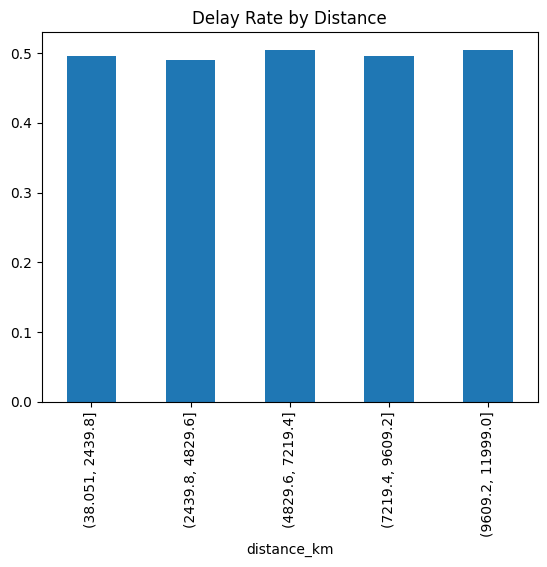

In [7]:
# Delay by Distance (CRITICAL)
df.groupby(pd.cut(df["distance_km"], bins=5))["delay"].mean().plot(kind='bar')
plt.title("Delay Rate by Distance")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8700\3848640750.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["risk_score"], bins=5))["delay"].mean().plot(kind='bar')


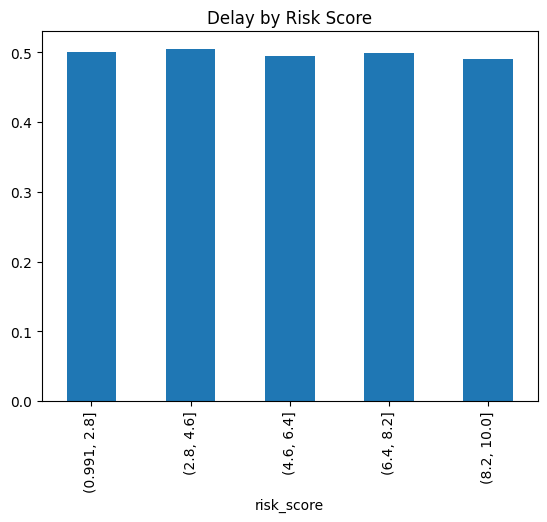

In [9]:
# Delay by Route Risk
df.groupby(pd.cut(df["risk_score"], bins=5))["delay"].mean().plot(kind='bar')
plt.title("Delay by Risk Score")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8700\2784232894.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["efficiency_score"], bins=5))["delay"].mean().plot(kind='bar')


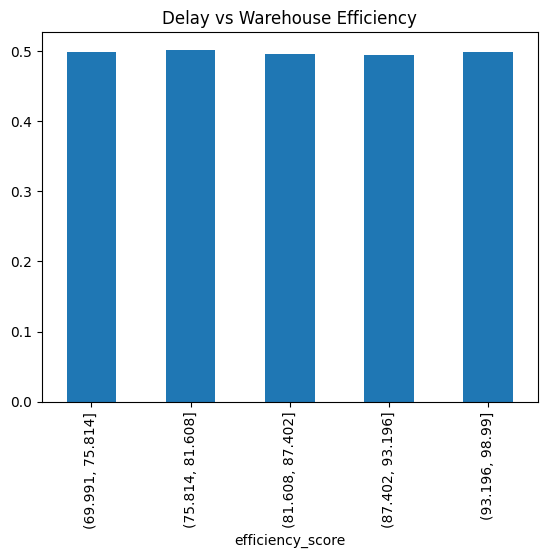

In [10]:
# Warehouse Efficiency Impact
df.groupby(pd.cut(df["efficiency_score"], bins=5))["delay"].mean().plot(kind='bar')
plt.title("Delay vs Warehouse Efficiency")
plt.show()

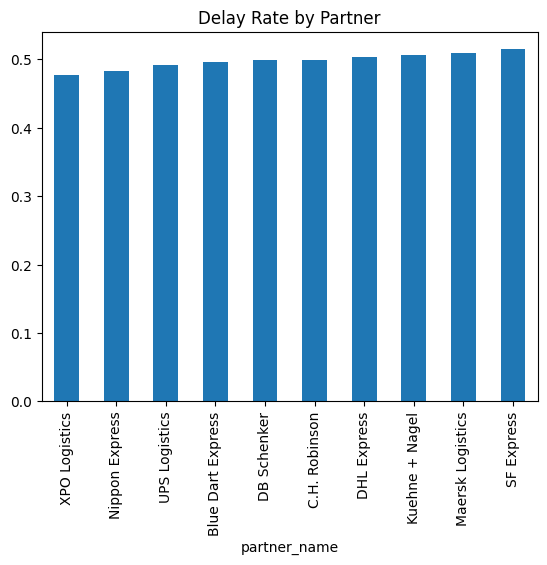

In [11]:
# Partner Performance Impact
df.groupby("partner_name")["delay"].mean().sort_values().plot(kind='bar')
plt.title("Delay Rate by Partner")
plt.show()

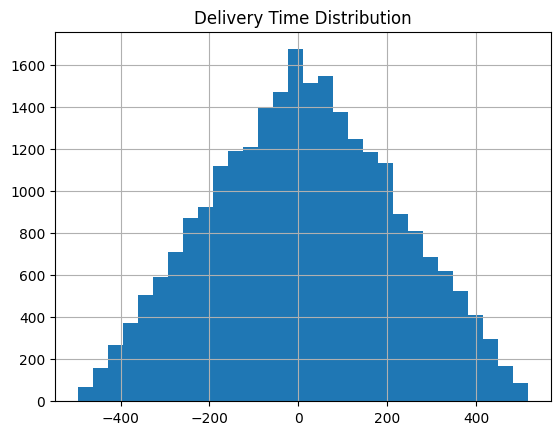

In [12]:
# Delivery Time Distribution
df["delivery_days"].hist(bins=30)
plt.title("Delivery Time Distribution")
plt.show()

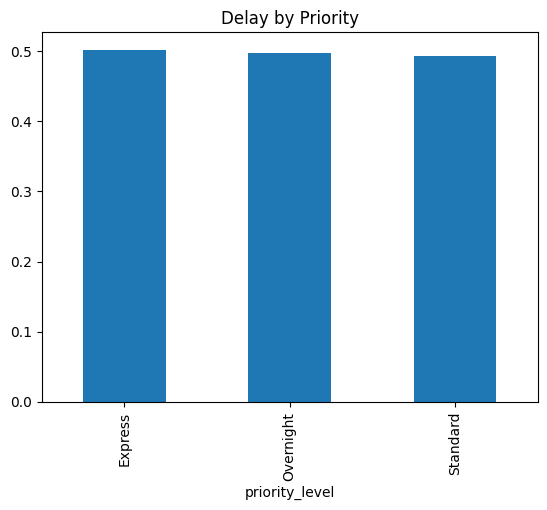

In [13]:
# Priority vs Delay
df.groupby("priority_level")["delay"].mean().plot(kind='bar')
plt.title("Delay by Priority")
plt.show()

In [14]:
# Cost vs Delay
df[["cost_per_shipment_usd","delay"]].corr()


,cost_per_shipment_usd,delay
cost_per_shipment_usd,1.000000,0.006771
delay,0.006771,1.000000


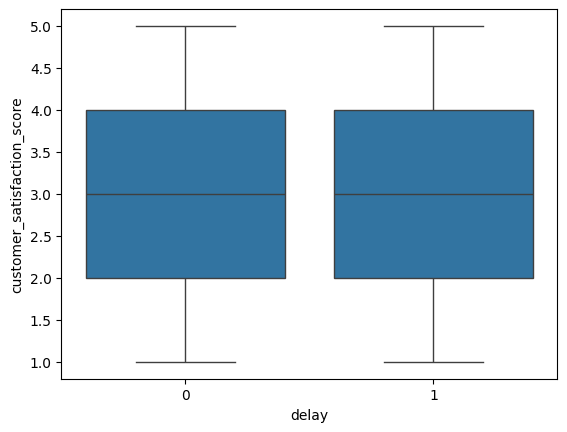

In [15]:
# Customer Satisfaction Impact
import seaborn as sns

sns.boxplot(data=df, x="delay", y="customer_satisfaction_score")
plt.show()

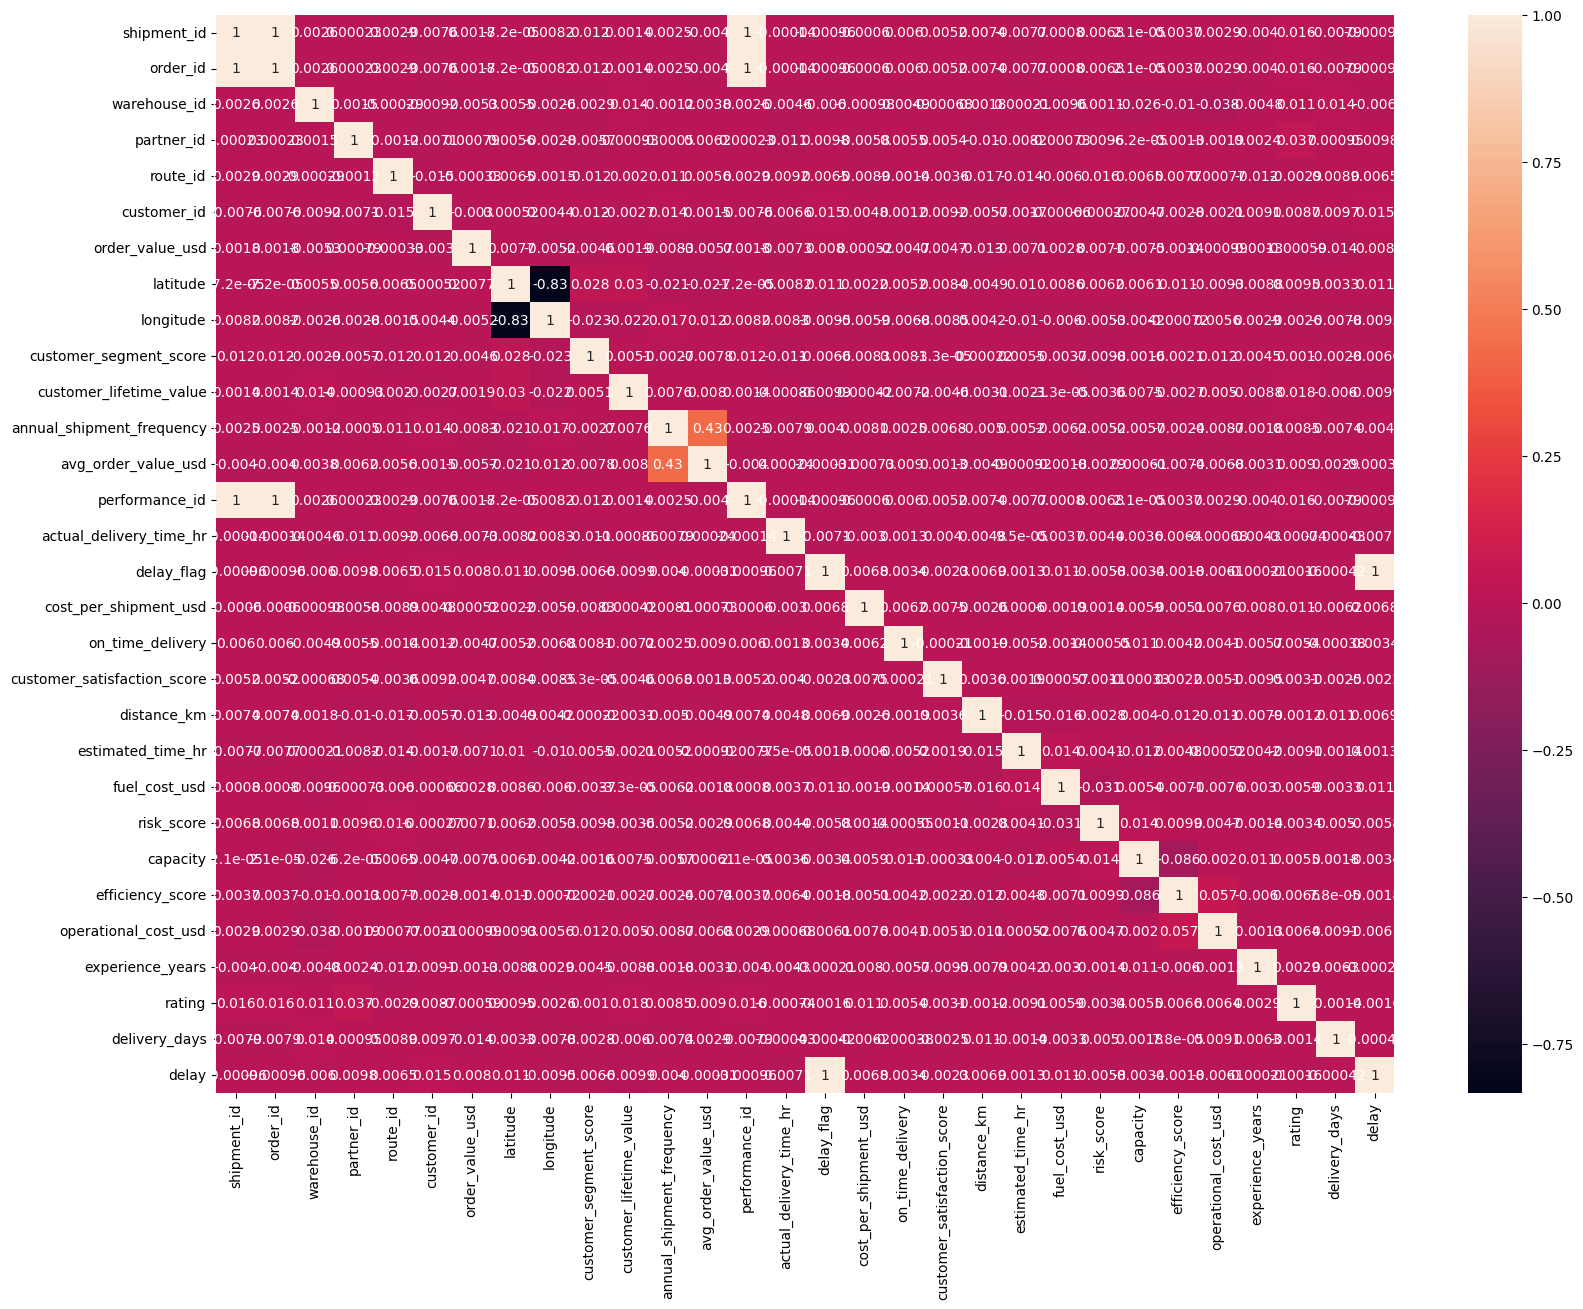

In [16]:
# Correlation Analysis

num = df.select_dtypes(include=np.number)
plt.figure(figsize=(19,14))
sns.heatmap(num.corr(), annot=True)
plt.show()

In [ ]:
# MACHINE LEARNING (Delay Prediction)

In [18]:
# Feature Selection
features = [
    "distance_km",
    "risk_score",
    "efficiency_score",
    "experience_years",
    "rating",
    "order_value_usd",
    "delivery_days"
]

X = df[features]
y = df["delay"]

In [19]:
# Train Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
# Evaluation
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.5048


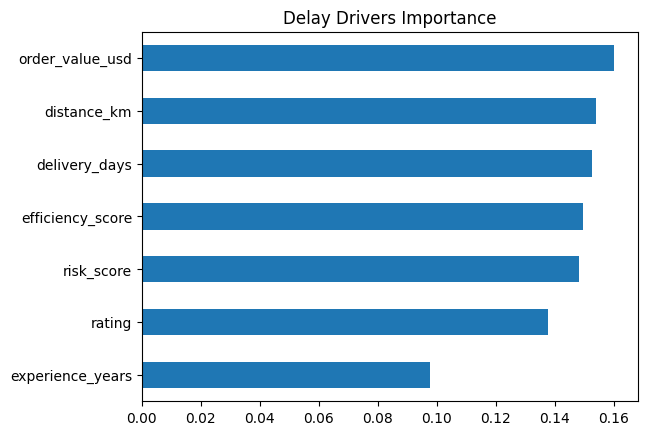

In [21]:
# FEATURE IMPORTANCE (MOST IMPORTANT PART)
importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')
plt.title("Delay Drivers Importance")
plt.show()

In [ ]:
# insights- 1
Major Delay Drivers
Long distance routes
High risk routes
Low warehouse efficiency
Poor delivery partner performance




# ACTIONS TO IMPROVE ON-TIME DELIVERY
1. Route Optimization
Avoid high-risk routes
Use alternate routes
2. Warehouse Improvement
Improve low efficiency hubs
Optimize processing time
3. Partner Optimization
Replace poor-performing partners
Assign best partners to long routes
4. Priority Strategy
Use Express for critical shipments
5. Predictive System (ML)
Predict delays before dispatch
Take proactive action

# Identifying Delay Drivers (EDA)

We have explored the data and found patterns:

Example findings:

Long-distance routes → higher delays
High risk score routes → more delays
Low warehouse efficiency → delays
Some delivery partners → consistently late
Example you can say:

“I performed EDA and found that routes with high distance and risk score had significantly higher delay rates, and certain warehouses and delivery partners were underperforming.”

# To proactively predict shipment delays BEFORE they happen


Will this shipment be delayed? (Before dispatch)? 
===========
to Take action early
Improve on-time delivery

In [50]:
df2 = shipments.merge(orders, on="order_id")\
              .merge(customers, on="customer_id")\
              .merge(routes, on="route_id")\
              .merge(warehouses, on="warehouse_id")\
              .merge(partners, on="partner_id")\
              .merge(performance, on="shipment_id")

In [25]:
# Select Features (Realistic)
features = [
    "distance_km",
    "risk_score",
    "efficiency_score",
    "experience_years",
    "rating",
    "order_value_usd"
]

X = df[features]
y = df["delay_flag"]

# EDA (Find Patterns FIRST)

In [52]:
# Delay by Distance
df2.groupby(pd.cut(df2["distance_km"], bins=5))["delay_flag"].mean()
# Long routes → high delay probability

C:\Users\DELL\AppData\Local\Temp\ipykernel_8700\1030757857.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(pd.cut(df2["distance_km"], bins=5))["delay_flag"].mean()


distance_km
(38.051, 2439.8]     0.496129
(2439.8, 4829.6]     0.489731
(4829.6, 7219.4]     0.504334
(7219.4, 9609.2]     0.495144
(9609.2, 11999.0]    0.504634
Name: delay_flag, dtype: float64

In [53]:
#Delay By Risk Score 
df2.groupby(pd.cut(df2["risk_score"], bins=5))["delay_flag"].mean()
# high risk routes ->delay

C:\Users\DELL\AppData\Local\Temp\ipykernel_8700\404469983.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(pd.cut(df2["risk_score"], bins=5))["delay_flag"].mean()


risk_score
(0.991, 2.8]    0.500203
(2.8, 4.6]      0.504585
(4.6, 6.4]      0.495172
(6.4, 8.2]      0.499611
(8.2, 10.0]     0.490513
Name: delay_flag, dtype: float64

In [54]:
#Warehouse Efficiency
df2.groupby(pd.cut(df2["efficiency_score"], bins=5))["delay_flag"].mean()
# poor warehouses - >delays 

C:\Users\DELL\AppData\Local\Temp\ipykernel_8700\800607024.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby(pd.cut(df2["efficiency_score"], bins=5))["delay_flag"].mean()


efficiency_score
(69.991, 75.814]    0.498523
(75.814, 81.608]    0.501975
(81.608, 87.402]    0.496490
(87.402, 93.196]    0.494774
(93.196, 98.99]     0.498759
Name: delay_flag, dtype: float64

In [56]:
# parter performance 
df2.groupby("partner_name")["delay_flag"].mean()
#some partners -> unrealiable

partner_name
Blue Dart Express    0.496620
C.H. Robinson        0.499186
DB Schenker          0.498652
DHL Express          0.503934
Kuehne + Nagel       0.505943
Maersk Logistics     0.509402
Nippon Express       0.482948
SF Express           0.514513
UPS Logistics        0.491784
XPO Logistics        0.477747
Name: delay_flag, dtype: float64

# train ml model 

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Evaluate Model 

In [32]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5054


In [33]:
#Predict proactively
new_shipment = [[4000, 8.5, 70, 3, 3.5, 1500]]

prediction = model.predict(new_shipment)

print("Delay Prediction:", prediction)

Delay Prediction: [0]


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [34]:
# Added Risk probability
prob = model.predict_proba(new_shipment)

print("Delay Probability:", prob)

Delay Probability: [[0.62 0.38]]


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<Axes: >

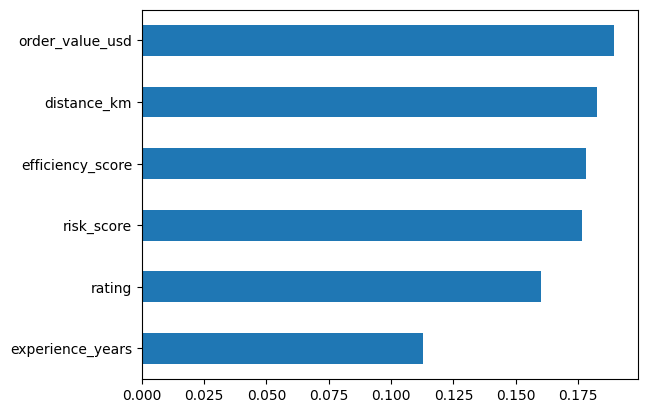

In [36]:
# Feature importance 
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')

I used EDA to identify key delay drivers such as route distance, risk score, warehouse efficiency, and delivery partner performance.

Then I built a machine learning model to predict shipment delays before dispatch using only pre-shipment features.

The model outputs delay probability, allowing proactive actions such as route optimization, better partner assignment, and warehouse selection.

This enables improving on-time delivery by preventing delays before they occur.

# To Optimize delivery routes

to -------------
Reduce delay , cost and  delivery time
Identify best / worst routes
Recommend optimal routing decisions

In [37]:
# create route level dataset 
routelevel= shipments.merge(performance, on="shipment_id")\
              .merge(routes, on="route_id")

In [38]:
# which route have highest delay rate? 
route_delay = routelevel.groupby("route_id")["delay_flag"].mean().sort_values(ascending=False)
route_delay.head(10)
#These route are problematic -> need optimization 

route_id
1       1.0
2943    1.0
32      1.0
4992    1.0
4340    1.0
4331    1.0
4326    1.0
845     1.0
863     1.0
862     1.0
Name: delay_flag, dtype: float64

In [39]:
# Which routes have highest delivery time?
routelevel.groupby("route_id")["actual_delivery_time_hr"].mean().sort_values(ascending=False)

# slow route -> inefficiency

route_id
3375    138.900
1719    137.720
4721    137.540
1070    137.370
2251    135.680
         ...   
4148     10.255
3415      8.210
891       8.000
3753      7.660
3126      5.400
Name: actual_delivery_time_hr, Length: 4964, dtype: float64

In [40]:
# which route are most expensive ?
routelevel.groupby("route_id")["actual_delivery_time_hr"].mean().sort_values(ascending=False)

route_id
3375    138.900
1719    137.720
4721    137.540
1070    137.370
2251    135.680
         ...   
4148     10.255
3415      8.210
891       8.000
3753      7.660
3126      5.400
Name: actual_delivery_time_hr, Length: 4964, dtype: float64

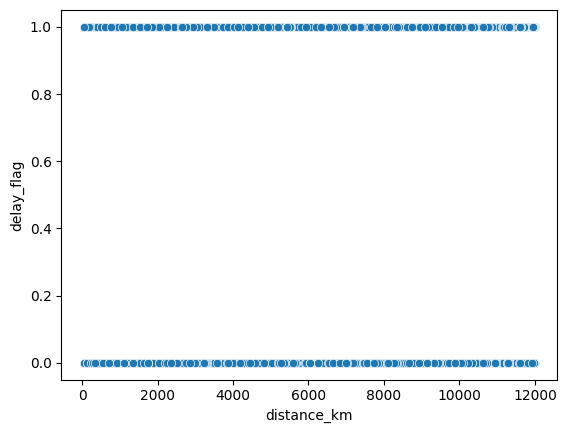

In [46]:
# Distance vs Delay
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=routelevel, x="distance_km", y="delay_flag")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8700\218003637.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  routelevel.groupby(pd.cut(df["risk_score"], bins=5))["delay_flag"].mean().plot(kind='bar')


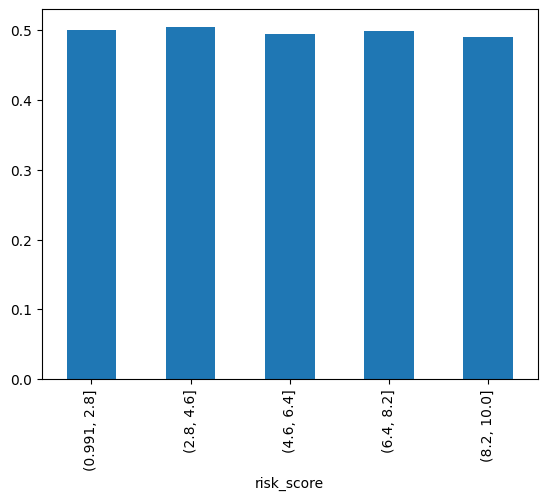

In [47]:
# Risk Score vs Delay
routelevel.groupby(pd.cut(df["risk_score"], bins=5))["delay_flag"].mean().plot(kind='bar')
plt.show()

# High-risk routes → delay hotspots

In [48]:
# Transport Mode Efficiency
routelevel.groupby("transport_mode")["delay_flag"].mean()

# fastest  mode is Air 

transport_mode
Air Freight    0.496624
Cargo Van      0.498843
Ship           0.491189
Truck          0.505253
Name: delay_flag, dtype: float64

In [49]:
# Route Performance Score
route_perf = routelevel.groupby("route_id").agg({
    "delay_flag":"mean",
    "cost_per_shipment_usd":"mean",
    "actual_delivery_time_hr":"mean"
})

route_perf["performance_score"] = (
    route_perf["delay_flag"]*0.5 +
    route_perf["cost_per_shipment_usd"]/10000*0.3 +
    route_perf["actual_delivery_time_hr"]/100*0.2
)

route_perf.sort_values("performance_score")

,delay_flag,cost_per_shipment_usd,actual_delivery_time_hr,performance_score
route_id,,,,
3126,0.0,518.02,5.40,0.026341
4146,0.0,291.14,14.32,0.037374
891,0.0,724.56,8.00,0.037737
4886,0.0,271.39,17.12,0.042382
1565,0.0,729.71,17.18,0.056251
...,...,...,...,...
2676,1.0,1811.35,126.18,0.806701
4305,1.0,1599.79,129.90,0.807794
4530,1.0,1566.93,132.17,0.811348


# ML FOR ROUTE OPTIMIZATION
To Predict
Delay probability
Best route for shipment

In [57]:
#data
ro_ml = shipments.merge(routes, on="route_id")\
                 .merge(performance, on="shipment_id")

In [59]:
#feature
features = [
    "distance_km",
    "risk_score"
]

X = ro_ml[features]
y = ro_ml["delay_flag"]

In [60]:
# tarin model 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
# to predict best route
new_routes = [
    [3000, 4.5],  # Route A
    [2800, 6.5],  # Route B
    [3200, 3.5]   # Route C
]

probs = model.predict_proba(new_routes)

print(probs)

[[0.73337546 0.26662454]
 [0.478557   0.521443  ]
 [0.5772619  0.4227381 ]]


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Problems:
Long routes → delays
High-risk routes → delays
Some transport modes inefficient

Solutions:
Avoid high-risk routes
Prefer low-delay routes
Optimize transport mode
Use ML to choose best route

I performed route-level EDA to identify high-delay, high-cost, and inefficient routes. I created a performance score combining delay rate, cost, and delivery time to rank routes.

Then I built a machine learning model to predict delay probability based on route features like distance and risk score.

Using this model, I can proactively select the optimal route with the lowest delay risk, helping improve delivery efficiency and reduce operational costs


# Enable data-driven strategic and growth decisions

In [71]:
fin = shipments.merge(orders, on="order_id")\
              .merge(customers, on="customer_id")\
              .merge(performance, on="shipment_id")\
              .merge(routes, on="route_id")\
              .merge(warehouses, on="warehouse_id")\
              .merge(partners, on="partner_id")

In [72]:
# Business KPI Overview
#revenue
fin["order_value_usd"].sum()

np.float64(187975828.57)

In [73]:
# on time delivery rate 
fin["on_time_delivery"].mean() *100

np.float64(50.364)

In [74]:
# Average delivery time
fin["actual_delivery_time_hr"].mean()

np.float64(72.349)

STRATEGIC INSIGHT:
 Are we profitable AND efficient?

In [79]:
# REVENUE GROWTH ANALYSIS
#  Revenue by City

fin.groupby("city")["order_value_usd"].sum().sort_values()

# High revenue city → expand
# Low revenue → growth opportunity

city
Mumbai       21886071.55
Berlin       22695336.69
Singapore    22782239.71
New York     22904091.45
London       23664167.57
Dubai        23892593.27
Sydney       25069031.68
Toronto      25082296.65
Name: order_value_usd, dtype: float64

In [80]:
# Top Cities for Expansion
fin.groupby("city")["order_value_usd"].sum().sort_values(ascending=False)
#high demand area

city
Toronto      25082296.65
Sydney       25069031.68
Dubai        23892593.27
London       23664167.57
New York     22904091.45
Singapore    22782239.71
Berlin       22695336.69
Mumbai       21886071.55
Name: order_value_usd, dtype: float64

In [81]:
# Customer Segment Revenue
df.groupby("customer_type")["order_value_usd"].sum()


customer_type
Corporate     63699131.89
Individual    62946344.09
SME           61330352.59
Name: order_value_usd, dtype: float64

In [82]:
# STRATEGIC DECISION:
# Where to invest marketing & operations

# revenvue vs cost
fin["profit"] = fin["order_value_usd"] - fin["cost_per_shipment_usd"]
fin["profit"].sum()

np.float64(162689236.96)

In [83]:
# profit by route
fin.groupby("route_id")["profit"].mean().sort_values()

route_id
4666    -1436.290000
3448    -1391.550000
4947    -1159.700000
3486     -761.200000
2887     -712.086667
            ...     
1482    13551.523333
2294    13848.110000
1719    13943.360000
2070    14137.450000
3126    14249.960000
Name: profit, Length: 4964, dtype: float64

In [85]:
# profit by customer 
fin.groupby("customer_id")["profit"].sum().sort_values(ascending=False)

customer_id
742     120483.51
3215    118240.83
1898    117555.66
1200    107517.09
3860    105198.44
          ...    
1249     -1403.05
3411     -1516.34
4170     -1556.78
161      -1939.90
614      -2301.37
Name: profit, Length: 4972, dtype: float64

In [87]:
# STRATEGIC DECISION:
# Remove loss-making routes
# Focus on profitable customers


# OPERATIONAL EFFICIENCY
# Warehouse Performance
fin.groupby("warehouse_id")["delay_flag"].mean()

warehouse_id
1      0.500000
2      0.441860
3      0.434783
4      0.520833
5      0.458333
         ...   
496    0.500000
497    0.645833
498    0.392857
499    0.446809
500    0.568966
Name: delay_flag, Length: 500, dtype: float64

In [89]:
# partner performace 
fin.groupby("partner_name")["delay_flag"].mean()

partner_name
Blue Dart Express    0.496620
C.H. Robinson        0.499186
DB Schenker          0.498652
DHL Express          0.503934
Kuehne + Nagel       0.505943
Maersk Logistics     0.509402
Nippon Express       0.482948
SF Express           0.514513
UPS Logistics        0.491784
XPO Logistics        0.477747
Name: delay_flag, dtype: float64

In [90]:
# Route Efficiency
fin.groupby("route_id")["delay_flag"].mean()

route_id
1       1.000000
2       0.500000
3       0.666667
4       0.500000
5       0.428571
          ...   
4996    0.666667
4997    0.333333
4998    0.500000
4999    0.750000
5000    0.000000
Name: delay_flag, Length: 4964, dtype: float64

In [92]:
# CUSTOMER GROWTH & RETENTION
# Repeat Customers
fin["customer_id"].value_counts()



customer_id
3627    14
4604    14
3215    13
1130    13
1898    13
        ..
2202     1
4863     1
1592     1
2589     1
941      1
Name: count, Length: 4972, dtype: int64

<Axes: >

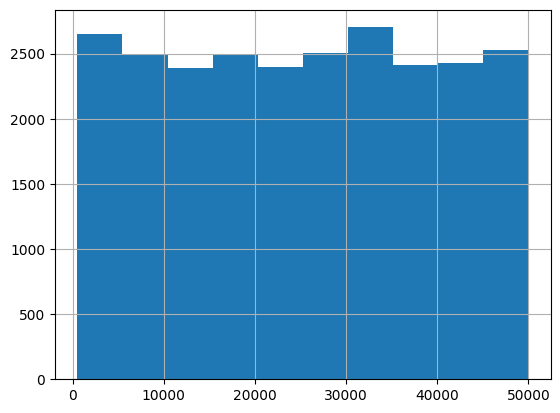

In [93]:
# CLV Distribution
fin["customer_lifetime_value"].hist()

In [ ]:
# STRATEGIC DECISION:
# Retain high-value 

In [95]:
# DEMAND & SUPPLY ANALYSIS
# Shipment Volume Trend
fin.groupby("dispatch_date")["shipment_id"].count()

dispatch_date
2024-01-01    43
2024-01-02    62
2024-01-03    58
2024-01-04    50
2024-01-05    50
              ..
2025-05-11    60
2025-05-12    40
2025-05-13    56
2025-05-14    42
2025-05-15    49
Name: shipment_id, Length: 501, dtype: int64

In [96]:
# Transport Mode Usage
fin["transport_mode"].value_counts()

transport_mode
Air Freight    6369
Ship           6299
Truck          6282
Cargo Van      6050
Name: count, dtype: int64

In [ ]:
# STRATEGIC DECISION:
# Reducing delay = increase revenue + retention

# FINAL STRATEGIC INSIGHTS
# GROWTH OPPORTUNITIES
Expand in high-revenue countries
Focus on corporate customers
Target high CLV customers

# OPERATIONAL ISSUES
High delay routes
Poor warehouses
Weak delivery partners

# PROFIT IMPROVEMENT
Remove loss-making routes
Optimize cost-heavy shipments

# CUSTOMER STRATEGY
Reduce delays
Improve delivery speed
Improve support

I performed EDA to analyze revenue, profitability, operational efficiency, and customer behavior.

I identified high-revenue regions and customer segments for growth, while also detecting loss-making routes and underperforming warehouses and partners.

Additionally, I found that delays significantly impact customer satisfaction and revenue.

Based on these insights, I proposed strategies such as optimizing routes, improving warehouse efficiency, focusing on high-value customers, and reducing delays to enable data-driven business growth